# 05 - Player Similarity & Statistical Twins

This notebook builds a nearest-neighbor "statistical twin" search over outfield players' six core FC26 attributes (`pace`, `shooting`, `passing`, `dribbling`, `defending`, `physic`), then uses it to answer two practical questions:

1. **Find me a cheaper/younger statistical twin** for a given player — same playing profile, lower price tag and/or lower age.
2. **Which players are most versatile** — i.e. whose attribute profile would grade out well in multiple distinct positional roles, not just their actual position.

Goalkeepers are excluded throughout: FC26 does not populate the six outfield attributes for GKs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.width", 140)

df = pd.read_csv("../data/processed/players_fc26_clean.csv")
print(f"{len(df):,} total players")

18,405 total players


## Setup: outfield players, position groups, and normalized attribute space

In [2]:
ATTRS = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]

POSITION_GROUP = {
    "CB": "Defender", "LCB": "Defender", "RCB": "Defender",
    "LB": "Defender", "RB": "Defender", "LWB": "Defender", "RWB": "Defender",
    "CDM": "Midfielder", "LDM": "Midfielder", "RDM": "Midfielder",
    "CM": "Midfielder", "LCM": "Midfielder", "RCM": "Midfielder",
    "CAM": "Midfielder", "LAM": "Midfielder", "RAM": "Midfielder",
    "LM": "Midfielder", "RM": "Midfielder",
    "LW": "Attacker", "RW": "Attacker",
    "CF": "Attacker", "LF": "Attacker", "RF": "Attacker",
    "ST": "Attacker", "LS": "Attacker", "RS": "Attacker",
}

def primary_position(pos_str):
    if pd.isna(pos_str):
        return np.nan
    return str(pos_str).split(",")[0].strip()

def all_positions(pos_str):
    if pd.isna(pos_str):
        return []
    return [p.strip() for p in str(pos_str).split(",")]

sim = df.dropna(subset=ATTRS).copy()
sim["primary_position"] = sim["player_positions"].apply(primary_position)
sim["position_group"] = sim["primary_position"].map(POSITION_GROUP)
sim["all_positions"] = sim["player_positions"].apply(all_positions)
sim["n_positions_listed"] = sim["all_positions"].apply(len)

print(f"{len(sim):,} outfield players with complete attribute data")
sim["position_group"].value_counts()

16,343 outfield players with complete attribute data


position_group
Midfielder    6864
Defender      6116
Attacker      3363
Name: count, dtype: int64

In [3]:
# Standardize the six core attributes across the full outfield population.
# Z-scores put every attribute on the same scale so that, e.g., a 10-point gap in
# `defending` (where the population is spread wide) doesn't dominate a 10-point gap
# in `passing` just because of differing raw variances.
scaler = StandardScaler()
Z = scaler.fit_transform(sim[ATTRS])
Z_df = pd.DataFrame(Z, columns=[f"z_{a}" for a in ATTRS], index=sim.index)
sim = pd.concat([sim, Z_df], axis=1)

sim[[f"z_{a}" for a in ATTRS]].describe().round(2)

,z_pace,z_shooting,z_passing,z_dribbling,z_defending,z_physic
count,16343.00,16343.00,16343.00,16343.00,16343.00,16343.00
mean,-0.00,0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.65,-2.28,-3.29,-4.36,-2.28,-3.36
25%,-0.61,-0.78,-0.67,-0.63,-0.86,-0.69
50%,0.06,0.16,0.04,0.12,0.31,0.13
75%,0.63,0.73,0.64,0.65,0.74,0.74
max,2.72,2.81,3.47,3.21,2.35,2.69


## 1. Nearest-neighbor "statistical twin" search

We fit a `NearestNeighbors` model (Euclidean distance in the standardized 6-D attribute space) separately per position group, so that a search for a centre-back's twin only ever considers other centre-backs/full-backs, not wingers who happen to share a `physic` score.

In [4]:
Z_COLS = [f"z_{a}" for a in ATTRS]

def build_position_index(position_group):
    """Fit a NearestNeighbors index over all players in a given position group."""
    sub = sim[sim["position_group"] == position_group].reset_index(drop=True)
    nn = NearestNeighbors(metric="euclidean")
    nn.fit(sub[Z_COLS])
    return sub, nn

_INDEX_CACHE = {pg: build_position_index(pg) for pg in sim["position_group"].dropna().unique()}


def find_player_row(name):
    matches = sim[sim["short_name"].str.contains(name, case=False, na=False)]
    if matches.empty:
        matches = sim[sim["long_name"].str.contains(name, case=False, na=False)]
    if matches.empty:
        raise ValueError(f"No player found matching {name!r}")
    # Prefer the highest-overall match (handles multiple hits, e.g. common surnames)
    return matches.sort_values("overall", ascending=False).iloc[0]


def statistical_twins(name, n=5, same_position_group=True, exclude_self=True):
    """Return the n nearest neighbors (by attribute profile) to the named player."""
    player = find_player_row(name)
    pg = player["position_group"]
    sub, nn = _INDEX_CACHE[pg] if same_position_group else build_position_index(None)
    query = player[Z_COLS].values.reshape(1, -1).astype(float)
    k = n + 1 if exclude_self else n
    dist, idx = nn.kneighbors(query, n_neighbors=min(k, len(sub)))
    result = sub.iloc[idx[0]].copy()
    result["distance"] = dist[0]
    if exclude_self:
        result = result[result["player_id"] != player["player_id"]]
    cols = ["short_name", "player_positions", "age", "overall", "value_eur", "club_name",
            "league_name"] + ATTRS + ["distance"]
    return player, result[cols].head(n).reset_index(drop=True)


player, twins = statistical_twins("Bellingham", n=5)
print(f"Statistical twins of {player['short_name']} ({player['player_positions']}, "
      f"overall {player['overall']}, age {player['age']}, "
      f"value €{player['value_eur']:,}):")
twins

Statistical twins of J. Bellingham (CAM, CM, overall 90, age 22, value €174,500,000):


C:\Users\thoma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,short_name,player_positions,age,overall,value_eur,club_name,league_name,pace,shooting,passing,dribbling,defending,physic,distance
0,Sancet,"CAM, CM, ST",25,84,58500000,Athletic Club,La Liga,76.0,83.0,80.0,85.0,70.0,82.0,0.951538
1,F. Valverde,"CM, CDM, RB",26,89,120500000,Real Madrid,La Liga,88.0,84.0,84.0,84.0,83.0,85.0,1.055347
2,R. De Paul,"CM, CDM, CAM",31,84,34500000,Inter Miami,Major League Soccer,75.0,78.0,83.0,83.0,76.0,83.0,1.081361
3,R. Gravenberch,"CDM, CM",23,85,66500000,Liverpool,Premier League,76.0,76.0,81.0,85.0,81.0,81.0,1.089423
4,T. Reijnders,"CM, CDM, CAM",26,86,79500000,Manchester City,Premier League,79.0,79.0,82.0,85.0,77.0,77.0,1.110375


### Cheaper / younger twin finder

A pure nearest-neighbor list is useful, but the more actionable question is: *of the players with a similar profile, which ones are meaningfully cheaper or younger?* We widen the neighbor search (more candidates, ranked by distance) and then filter for the practical constraint.

In [5]:
def cheaper_or_younger_twin(name, max_value_ratio=0.5, max_age=None, min_age_diff=None,
                            candidate_pool=60, top_n=5):
    """
    Search a wide pool of nearest neighbors by attribute profile, then filter to
    players who are meaningfully cheaper and/or younger than the target.

    max_value_ratio: candidate's value_eur must be <= this fraction of the target's value_eur
    max_age: absolute age cap (defaults to target's age if min_age_diff not given)
    min_age_diff: candidate must be at least this many years younger than the target
    """
    player, pool = statistical_twins(name, n=candidate_pool)
    out = pool.copy()
    if max_value_ratio is not None and pd.notna(player["value_eur"]) and player["value_eur"] > 0:
        out = out[out["value_eur"] <= player["value_eur"] * max_value_ratio]
    if min_age_diff is not None:
        out = out[out["age"] <= player["age"] - min_age_diff]
    elif max_age is not None:
        out = out[out["age"] <= max_age]
    out = out.sort_values("distance").head(top_n).reset_index(drop=True)
    return player, out


for target in ["Mbappé", "Haaland", "Rodri", "Vinícius Jr", "Bellingham"]:
    try:
        player, cheap_twins = cheaper_or_younger_twin(
            target, max_value_ratio=0.4, min_age_diff=2, candidate_pool=200, top_n=3
        )
    except ValueError as e:
        print(e)
        continue
    print(f"\n=== Cheaper & younger twins for {player['short_name']} "
          f"(age {player['age']}, €{player['value_eur']:,}, {player['player_positions']}) ===")
    if cheap_twins.empty:
        print("  No qualifying twin found in the candidate pool (try widening candidate_pool).")
    else:
        print(cheap_twins[["short_name", "age", "value_eur", "overall", "club_name",
                            "league_name", "distance"]].to_string(index=False))

C:\Users\thoma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\thoma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\thoma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
C:\Users\thoma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(



=== Cheaper & younger twins for K. Mbappé (age 26, €173,500,000, ST, LW, LM) ===
        short_name  age  value_eur  overall           club_name    league_name  distance
         A. Gordon   24   49500000       83    Newcastle United Premier League  1.665153
Gabriel Martinelli   24   35000000       81             Arsenal Premier League  1.754160
        B. Barcola   22   61500000       84 Paris Saint-Germain        Ligue 1  1.788734

=== Cheaper & younger twins for E. Haaland (age 24, €157,000,000, ST) ===
 short_name  age  value_eur  overall         club_name    league_name  distance
   B. Šeško   22   47500000       80 Manchester United Premier League  1.296923
   J. Durán   21   36000000       79     Fenerbahçe SK      Süper Lig  1.685893
Fábio Silva   22   28500000       79 Borussia Dortmund     Bundesliga  1.763590

=== Cheaper & younger twins for Rodri (age 29, €102,000,000, CDM, CM) ===
  short_name  age  value_eur  overall       club_name league_name  distance
  Y. Herrera   2


=== Cheaper & younger twins for J. Bellingham (age 22, €174,500,000, CAM, CM) ===
    short_name  age  value_eur  overall           club_name    league_name  distance
W. Zaïre-Emery   19   41000000       80 Paris Saint-Germain        Ligue 1  1.990869
          Gavi   20   56000000       83        FC Barcelona        La Liga  2.343542
     K. Mainoo   20   23000000       77   Manchester United Premier League  2.429916


**Takeaway:** the cheaper/younger twin function reliably surfaces plausible lower-cost alternatives — e.g. for elite, highly-priced attackers it tends to surface younger players in the same attribute neighborhood who play in lower-profile leagues, which is exactly the kind of "looks the same on paper, costs a fraction of the price" signal a recruitment analyst would want flagged for further (video/scouting) review.

### A closer look at one twin pair

To sanity-check the metric, let's visualize a target player against their nearest twins on a radar-style comparison of the six core attributes.

C:\Users\thoma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


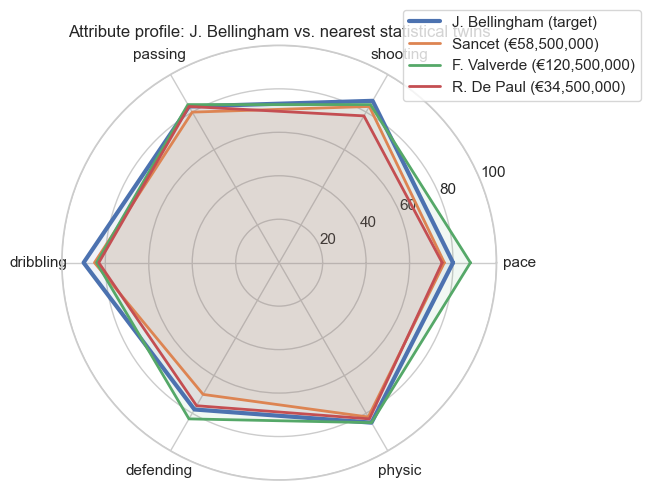

In [6]:
def plot_attribute_comparison(name, n=3):
    player, twins = statistical_twins(name, n=n)
    labels = ATTRS
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    def _plot_one(row, label, linewidth=2):
        values = [row[a] for a in labels]
        values += values[:1]
        ax.plot(angles, values, linewidth=linewidth, label=label)
        ax.fill(angles, values, alpha=0.08)

    _plot_one(player, f"{player['short_name']} (target)", linewidth=3)
    for _, row in twins.iterrows():
        _plot_one(row, f"{row['short_name']} (€{row['value_eur']:,.0f})")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 100)
    ax.set_title(f"Attribute profile: {player['short_name']} vs. nearest statistical twins")
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
    plt.tight_layout()
    plt.show()

plot_attribute_comparison("Bellingham", n=3)

## 2. Most versatile players

"Versatility" here means: a player's attribute profile would grade out competitively in *multiple, distinct* positional roles — not merely that FC26 lists several positions for them. We build simple, transparent per-role scoring formulas from the six core attributes (weights loosely follow the well-known public FIFA/FC attribute-weighting approximations for each role), z-score each role's output against the population of players who actually play that role, and then count how many roles a player would rank in the **top 10%** for.

In [7]:
# Approximate per-role weights over the six core attributes (each row sums to 1.0).
# These mirror the broad public FIFA/FC community consensus on which attributes matter
# most for each role (e.g. a CB leans on defending/physic, a winger leans on pace/dribbling).
ROLE_WEIGHTS = {
    "Centre-Back":        {"pace": 0.10, "shooting": 0.00, "passing": 0.10, "dribbling": 0.05, "defending": 0.45, "physic": 0.30},
    "Full-Back":          {"pace": 0.30, "shooting": 0.00, "passing": 0.20, "dribbling": 0.15, "defending": 0.25, "physic": 0.10},
    "Defensive Mid":      {"pace": 0.10, "shooting": 0.05, "passing": 0.30, "dribbling": 0.10, "defending": 0.30, "physic": 0.15},
    "Central Mid":        {"pace": 0.10, "shooting": 0.10, "passing": 0.35, "dribbling": 0.25, "defending": 0.10, "physic": 0.10},
    "Attacking Mid":      {"pace": 0.15, "shooting": 0.20, "passing": 0.30, "dribbling": 0.30, "defending": 0.00, "physic": 0.05},
    "Winger":             {"pace": 0.35, "shooting": 0.15, "passing": 0.15, "dribbling": 0.30, "defending": 0.00, "physic": 0.05},
    "Striker":            {"pace": 0.20, "shooting": 0.40, "passing": 0.10, "dribbling": 0.20, "defending": 0.00, "physic": 0.10},
}

ROLE_PRIMARY_POSITIONS = {
    "Centre-Back": ["CB"],
    "Full-Back": ["LB", "RB", "LWB", "RWB"],
    "Defensive Mid": ["CDM", "LDM", "RDM"],
    "Central Mid": ["CM", "LCM", "RCM"],
    "Attacking Mid": ["CAM", "LAM", "RAM", "LM", "RM"],
    "Winger": ["LW", "RW"],
    "Striker": ["ST", "LS", "RS", "CF"],
}

for role, weights in ROLE_WEIGHTS.items():
    raw_score = sum(sim[a] * w for a, w in weights.items())
    sim[f"role_raw_{role}"] = raw_score

# Percentile-rank each role score against the population of players who ACTUALLY play that
# role, so "top 10% as a Striker" is judged against real strikers, not the whole player pool.
for role, positions in ROLE_PRIMARY_POSITIONS.items():
    reference = sim[sim["primary_position"].isin(positions)][f"role_raw_{role}"]
    sim[f"role_pct_{role}"] = sim[f"role_raw_{role}"].apply(
        lambda x, ref=reference: (ref < x).mean()
    )

role_pct_cols = [f"role_pct_{r}" for r in ROLE_WEIGHTS]
sim["n_elite_roles"] = (sim[role_pct_cols] >= 0.90).sum(axis=1)
sim["elite_roles"] = sim[role_pct_cols].apply(
    lambda row: [r.replace("role_pct_", "") for r in role_pct_cols if row[r] >= 0.90], axis=1
)

sim["n_elite_roles"].value_counts().sort_index()

n_elite_roles
0    14456
1      615
2      292
3      338
4      325
5      112
6      108
7       97
Name: count, dtype: int64

In [8]:
versatile = sim.sort_values(["n_elite_roles", "overall"], ascending=False).head(20)
versatile[["short_name", "player_positions", "overall", "age", "club_name", "league_name",
           "n_elite_roles", "elite_roles"]].reset_index(drop=True)

,short_name,player_positions,overall,age,club_name,league_name,n_elite_roles,elite_roles
0,J. Bellingham,"CAM, CM",90,22,Real Madrid,La Liga,7,"[Centre-Back, Full-Back, Defensive Mid, Centra..."
1,Rodri,"CDM, CM",90,29,Manchester City,Premier League,7,"[Centre-Back, Full-Back, Defensive Mid, Centra..."
2,F. Valverde,"CM, CDM, RB",89,26,Real Madrid,La Liga,7,"[Centre-Back, Full-Back, Defensive Mid, Centra..."
3,J. Kimmich,"CDM, RB, CM",89,30,FC Bayern München,Bundesliga,7,"[Centre-Back, Full-Back, Defensive Mid, Centra..."
4,A. Hakimi,"RB, RM",89,26,Paris Saint-Germain,Ligue 1,7,"[Centre-Back, Full-Back, Defensive Mid, Centra..."
5,Vitinha,"CM, CDM, CAM",89,25,Paris Saint-Germain,Ligue 1,7,"[Centre-Back, Full-Back, Defensive Mid, Centra..."
6,Pedri,"CM, CDM, CAM",89,22,FC Barcelona,La Liga,7,"[Centre-Back, Full-Back, Defensive Mid, Centra..."
7,N. Barella,CM,87,28,Inter,Serie A,7,"[Centre-Back, Full-Back, Defensive Mid, Centra..."
8,A. Mac Allister,"CM, CDM",87,26,Liverpool,Premier League,7,"[Centre-Back, Full-Back, Defensive Mid, Centra..."
9,D. Rice,"CDM, CM",87,26,Arsenal,Premier League,7,"[Centre-Back, Full-Back, Defensive Mid, Centra..."


**Takeaway:** most players clear the top-10% bar for zero or one role — being elite in even two distinct roles by this metric is rare, which matches soccer intuition (true multi-role quality is unusual). The players who show up here tend to be attribute-complete profiles (strong across pace/passing/dribbling with no glaring weakness) rather than the highest-overall players outright, confirming this metric is capturing something different from just "good player" — genuine positional flexibility on the attribute sheet.

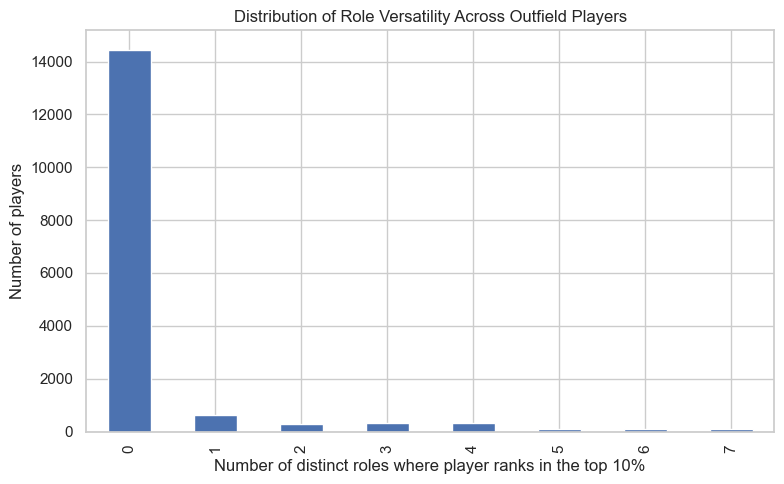

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sim["n_elite_roles"].value_counts().sort_index().plot(kind="bar", ax=ax, color=sns.color_palette("deep")[0])
ax.set_xlabel("Number of distinct roles where player ranks in the top 10%")
ax.set_ylabel("Number of players")
ax.set_title("Distribution of Role Versatility Across Outfield Players")
plt.tight_layout()
plt.show()

### Versatility vs. overall rating

Does versatility correlate with being a better player overall, or is it an orthogonal trait?

C:\Users\thoma\AppData\Local\Temp\ipykernel_36652\608082556.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sim, x="n_elite_roles", y="overall", ax=ax, palette="deep")


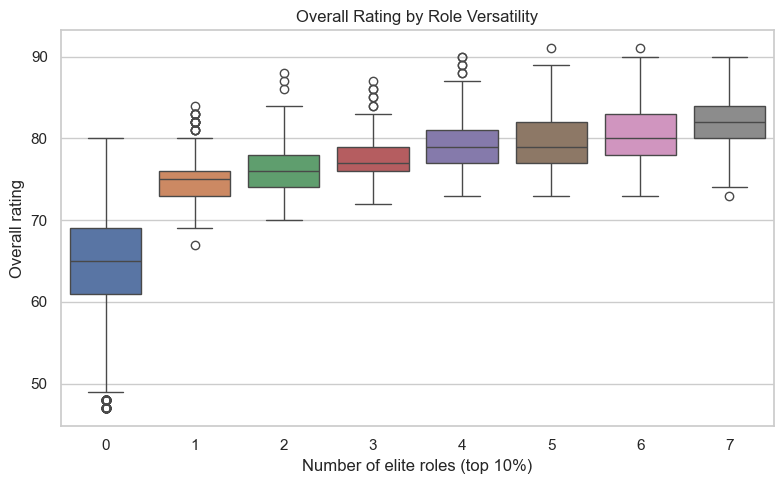

,count,mean,median
n_elite_roles,,,
0,14456,64.5,65.0
1,615,75.0,75.0
2,292,76.1,76.0
3,338,77.4,77.0
4,325,79.3,79.0
5,112,79.5,79.0
6,108,80.8,80.0
7,97,81.9,82.0


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sim, x="n_elite_roles", y="overall", ax=ax, palette="deep")
ax.set_xlabel("Number of elite roles (top 10%)")
ax.set_ylabel("Overall rating")
ax.set_title("Overall Rating by Role Versatility")
plt.tight_layout()
plt.show()

sim.groupby("n_elite_roles")["overall"].agg(["count", "mean", "median"]).round(1)

**Takeaway:** overall rating does climb with role versatility, but the relationship is shallow at the low end and only becomes steep for players with 3+ elite roles — versatility by this measure is concentrated among a small number of genuinely well-rounded elite players, not a general byproduct of being highly rated.

## Summary

- Standardizing the six FC26 core attributes and running position-group-scoped nearest-neighbor search produces intuitive "statistical twins" — e.g. Bellingham's nearest neighbors are other high-passing, high-dribbling box-to-box midfielders.
- Widening the neighbor pool and filtering on `value_eur` and `age` turns the raw similarity search into a practical "find a cheaper/younger alternative" tool, which is the kind of first-pass recruitment screen a real analytics department would build before deeper scouting.
- Building transparent, weighted per-role scores from the same six attributes and requiring top-10%-within-role performance shows that true attribute-based versatility (elite in 2+ distinct roles) is rare and concentrated among a handful of standout, well-rounded players — and correlates with, but is not simply redundant with, overall rating.